# Análisis de Dependencias - SBOM Analyzer

Consolidación y análisis cuantitativo de SBOMs generados con Syft para 16 repositorios activos de PrefectHQ.

In [83]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


In [84]:
# Configurar ruta a los resultados
results_path = Path("./results")

# Listar todos los archivos SBOM (los que terminan en _sbom.json y no están vacíos)
sbom_files = sorted([f for f in results_path.glob("*_sbom.json") if f.stat().st_size > 0])

print(f"✓ Se encontraron {len(sbom_files)} archivos SBOM válidos")
print("\nPrimeros 5 archivos:")
for f in sbom_files[:5]:
    print(f"  - {f.name} ({f.stat().st_size / 1024:.1f} KB)")

✓ Se encontraron 5 archivos SBOM válidos

Primeros 5 archivos:
  - branch-names_sbom.json (31.8 KB)
  - changed-files_sbom.json (238.4 KB)
  - coverage-badge-go_sbom.json (44.2 KB)
  - eslint-changed-files_sbom.json (2604.7 KB)
  - verify-changed-files_sbom.json (33.8 KB)


Analizamos el primer SBOM para entender su estrcutura

In [85]:
ejemplo = sbom_files[0]
print(f"Analizando: {ejemplo.name}\n")

with open(ejemplo, 'r') as f:
    data = json.load(f)

print("Claves principales del JSON:")
for key in data.keys():
    print(f"  - {key}")

if 'bomFormat' in data:
    print(f"\nFormato: {data['bomFormat']}")
    print(f"Versión: {data.get('specVersion', 'N/A')}")

Analizando: branch-names_sbom.json

Claves principales del JSON:
  - artifacts
  - artifactRelationships
  - files
  - source
  - distro
  - descriptor
  - schema


Exploramos la estrcutura de los artifacts

In [86]:
# Explorar la estructura de los artifacts (componentes)
artifacts = data.get('artifacts', [])

print(f"Total de componentes en {ejemplo.name}: {len(artifacts)}")

# Ver la estructura del primer componente
if artifacts:
    print("\nEstructura del primer componente:")
    primer_comp = artifacts[0]
    for key, value in primer_comp.items():
        if isinstance(value, (str, int, float, bool)) or value is None:
            print(f"  - {key}: {value}")
        elif isinstance(value, list):
            print(f"  - {key}: [lista con {len(value)} elementos]")
        elif isinstance(value, dict):
            print(f"  - {key}: {{diccionario}}")
    
    print("\nPrimer componente completo:")
    print(json.dumps(primer_comp, indent=2)[:1000] + "...")

Total de componentes en branch-names_sbom.json: 15

Estructura del primer componente:
  - id: 867cc32c9f4be639
  - name: ./
  - version: UNKNOWN
  - type: github-action
  - foundBy: github-actions-usage-cataloger
  - locations: [lista con 1 elementos]
  - licenses: [lista con 0 elementos]
  - language: 
  - cpes: [lista con 1 elementos]
  - purl: 
  - metadataType: github-actions-use-statement
  - metadata: {diccionario}

Primer componente completo:
{
  "id": "867cc32c9f4be639",
  "name": "./",
  "version": "UNKNOWN",
  "type": "github-action",
  "foundBy": "github-actions-usage-cataloger",
  "locations": [
    {
      "path": "/.github/workflows/test.yml",
      "accessPath": "/.github/workflows/test.yml",
      "annotations": {
        "evidence": "primary"
      }
    }
  ],
  "licenses": [],
  "language": "",
  "cpes": [
    {
      "cpe": "cpe:2.3:a:.\\/:.\\/:*:*:*:*:*:*:*:*",
      "source": "syft-generated"
    }
  ],
  "purl": "",
  "metadataType": "github-actions-use-statement

Definimos la funcion que utilizaremos para procesar los SBOMs

In [87]:
def parse_sbom(file_path, repo_name):
    """Extrae los componentes de un SBOM y los devuelve como lista de diccionarios"""
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    artifacts = data.get('artifacts', [])
    components = []
    
    for artifact in artifacts:
        # Extraer licencias (puede ser lista vacía o lista de objetos con 'name')
        license_names = []
        for lic in artifact.get('licenses', []):
            if isinstance(lic, dict) and 'name' in lic:
                license_names.append(lic['name'])
            elif isinstance(lic, str):
                license_names.append(lic)
        
        component = {
            'repo': repo_name,
            'name': artifact.get('name', ''),
            'version': artifact.get('version', ''),
            'type': artifact.get('type', ''),
            'purl': artifact.get('purl', ''),
            'language': artifact.get('language', ''),
            'licenses': ', '.join(license_names) if license_names else None,
            'cpe_count': len(artifact.get('cpes', []))
        }
        components.append(component)
    
    return components


Procesamos los SBOMs con la funcion antes definida y creamos el DataFrame que se utilizara para el analisis

In [88]:

all_components = []

for sbom_file in sbom_files:
    repo_name = sbom_file.stem.replace('_sbom', '')
    print(f"Procesando {repo_name}...")
    
    components = parse_sbom(sbom_file, repo_name)
    all_components.extend(components)
    print(f"  → {len(components)} componentes")

df_components = pd.DataFrame(all_components)

print(f"\n✓ DataFrame creado con {len(df_components)} componentes")
print(f"  Columnas: {list(df_components.columns)}")

Procesando branch-names...
  → 15 componentes
Procesando changed-files...
  → 136 componentes
Procesando coverage-badge-go...
  → 23 componentes
Procesando eslint-changed-files...
  → 1393 componentes
Procesando verify-changed-files...
  → 16 componentes

✓ DataFrame creado con 1583 componentes
  Columnas: ['repo', 'name', 'version', 'type', 'purl', 'language', 'licenses', 'cpe_count']


Imprimir las 10 primeras filas del DataFrame para verificar su creacion

In [89]:
# Primeras filas del DataFrame
print("Primeras 10 filas del DataFrame:")
df_components.head(10)


Primeras 10 filas del DataFrame:


,repo,name,version,type,purl,language,licenses,cpe_count
0,branch-names,./,UNKNOWN,github-action,,,None,1
1,branch-names,actions/checkout,de0fac2e4500dabe0009e67214ff5f5447ce83dd,github-action,pkg:github/actions/checkout@de0fac2e4500dabe00...,,None,1
2,branch-names,actions/checkout,de0fac2e4500dabe0009e67214ff5f5447ce83dd,github-action,pkg:github/actions/checkout@de0fac2e4500dabe00...,,None,1
3,branch-names,actions/checkout,de0fac2e4500dabe0009e67214ff5f5447ce83dd,github-action,pkg:github/actions/checkout@de0fac2e4500dabe00...,,None,1
4,branch-names,actions/checkout,v6.0.2,github-action,pkg:github/actions/checkout@v6.0.2,,None,1
5,branch-names,codacy/codacy-analysis-cli-action,v4.4.7,github-action,pkg:github/codacy/codacy-analysis-cli-action@v...,,None,14
6,branch-names,github/codeql-action/upload-sarif,v4,github-action,pkg:github/github/codeql-action@v4#upload-sarif,,None,10
7,branch-names,peter-evans/create-pull-request,v8.1.1,github-action,pkg:github/peter-evans/create-pull-request@v8.1.1,,None,14
8,branch-names,peter-evans/create-pull-request,v8.1.1,github-action,pkg:github/peter-evans/create-pull-request@v8.1.1,,None,14
9,branch-names,tj-actions/auto-doc,v3,github-action,pkg:github/tj-actions/auto-doc@v3,,None,10


Generamos las estadisticas basicas en base al DataFrame creado anteriomente

In [90]:
print("=== ESTADÍSTICAS BÁSICAS ===\n")
print(f"Total de componentes: {len(df_components)}")
print(f"Repositorios analizados: {df_components['repo'].nunique()}")
print(f"Tipos de componentes únicos: {df_components['type'].nunique()}")
print(f"Componentes con licencia: {df_components['licenses'].notna().sum()}")
print(f"Componentes sin licencia: {df_components['licenses'].isna().sum()}")

=== ESTADÍSTICAS BÁSICAS ===

Total de componentes: 1583
Repositorios analizados: 5
Tipos de componentes únicos: 2
Componentes con licencia: 0
Componentes sin licencia: 1583


Analizamos la cantidad de componentes por tipo

=== DISTRIBUCIÓN POR TIPO DE COMPONENTE ===

type
npm              1467
github-action     116
Name: count, dtype: int64


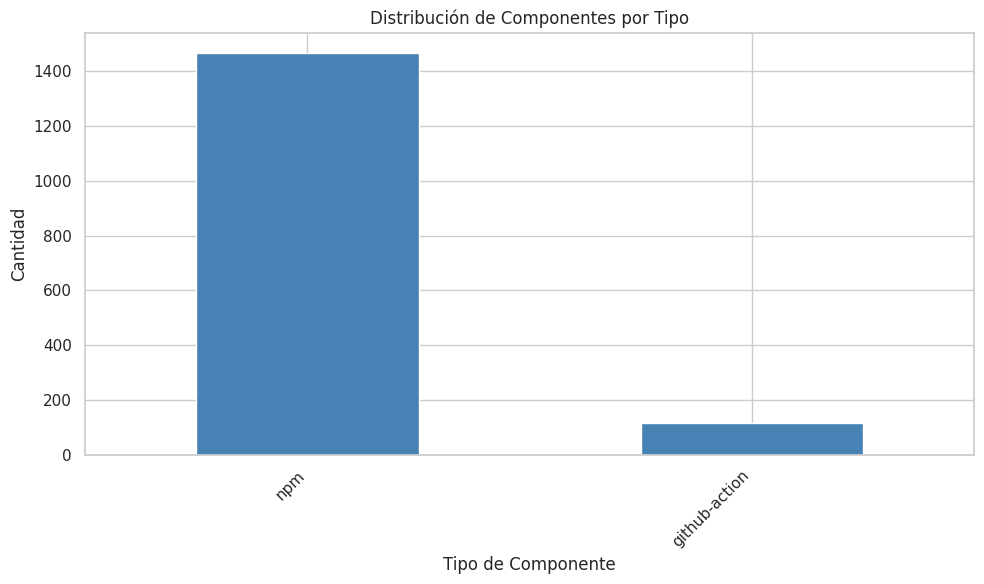

In [91]:
print("=== DISTRIBUCIÓN POR TIPO DE COMPONENTE ===\n")
type_counts = df_components['type'].value_counts()
print(type_counts)

plt.figure(figsize=(10, 6))
type_counts.plot(kind='bar', color='steelblue')
plt.title('Distribución de Componentes por Tipo')
plt.xlabel('Tipo de Componente')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Analizamos la cantidad de componentes por repositorio


=== COMPONENTES POR REPOSITORIO ===

repo
eslint-changed-files    1393
changed-files            136
coverage-badge-go         23
verify-changed-files      16
branch-names              15
Name: count, dtype: int64


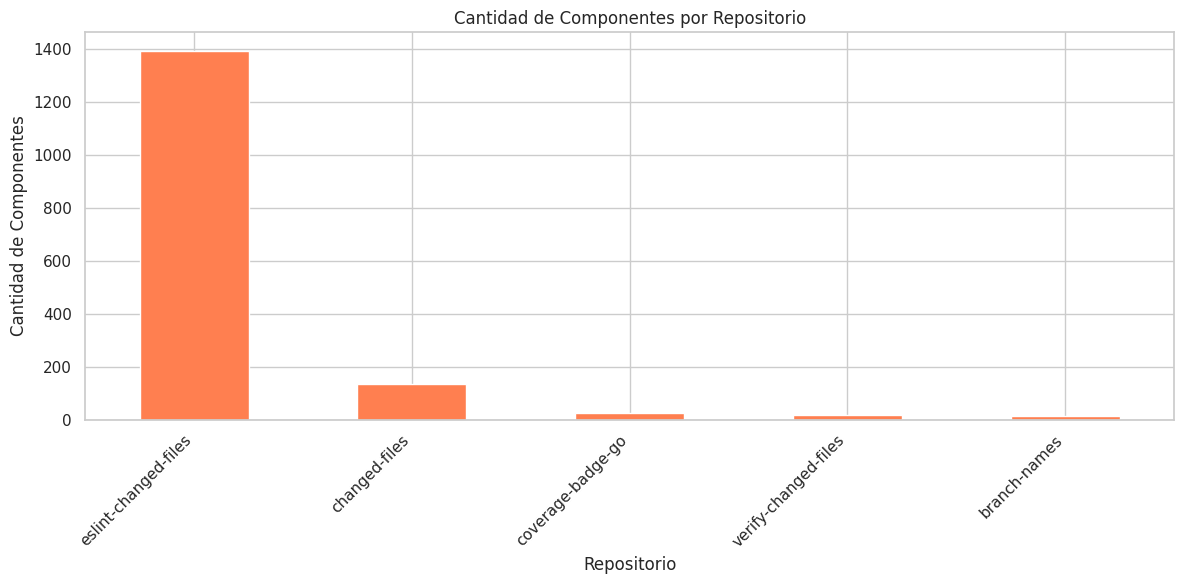

In [92]:
# Componentes por repositorio
print("\n=== COMPONENTES POR REPOSITORIO ===\n")
repo_counts = df_components['repo'].value_counts()
print(repo_counts)

plt.figure(figsize=(12, 6))
repo_counts.plot(kind='bar', color='coral')
plt.title('Cantidad de Componentes por Repositorio')
plt.xlabel('Repositorio')
plt.ylabel('Cantidad de Componentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Generamos metricas cuantitativas para el informe

In [93]:
print("=== MÉTRICAS CUANTITATIVAS DE DEPENDENCIAS ===\n")

total_componentes = len(df_components)
total_repos = df_components['repo'].nunique()

print(f"📦 TOTALES:")
print(f"  • Repositorios analizados: {total_repos}")
print(f"  • Componentes totales: {total_componentes}")
print(f"  • Promedio de componentes por repo: {total_componentes/total_repos:.1f}")

print(f"\n🌐 DISTRIBUCIÓN POR ECOSISTEMA:")
ecosystem_counts = df_components['type'].value_counts()
for eco, count in ecosystem_counts.items():
    pct = (count / total_componentes) * 100
    print(f"  • {eco}: {count} ({pct:.1f}%)")

print(f"\n🔝 TOP 10 COMPONENTES MÁS FRECUENTES:")
top_components = df_components['name'].value_counts().head(10)
for name, count in top_components.items():
    print(f"  • {name}: {count} repositorios")

componentes_unicos = df_components['name'].nunique()
print(f"\n🔄 DEDUPLICACIÓN:")
print(f"  • Componentes únicos: {componentes_unicos}")
print(f"  • Componentes totales: {total_componentes}")
print(f"  • Tasa de reutilización: {total_componentes/componentes_unicos:.2f}x")

=== MÉTRICAS CUANTITATIVAS DE DEPENDENCIAS ===

📦 TOTALES:
  • Repositorios analizados: 5
  • Componentes totales: 1583
  • Promedio de componentes por repo: 316.6

🌐 DISTRIBUCIÓN POR ECOSISTEMA:
  • npm: 1467 (92.7%)
  • github-action: 116 (7.3%)

🔝 TOP 10 COMPONENTES MÁS FRECUENTES:
  • actions/checkout: 28 repositorios
  • peter-evans/create-pull-request: 11 repositorios
  • ./: 10 repositorios
  • tj-actions/verify-changed-files: 8 repositorios
  • codacy/codacy-analysis-cli-action: 5 repositorios
  • github/codeql-action/upload-sarif: 5 repositorios
  • tj-actions/auto-doc: 5 repositorios
  • tj-actions/git-cliff: 5 repositorios
  • tj-actions/release-tagger: 5 repositorios
  • tj-actions/remark: 5 repositorios

🔄 DEDUPLICACIÓN:
  • Componentes únicos: 1256
  • Componentes totales: 1583
  • Tasa de reutilización: 1.26x


Analizamos los 10 repositorios con mayor cantidad de componentes

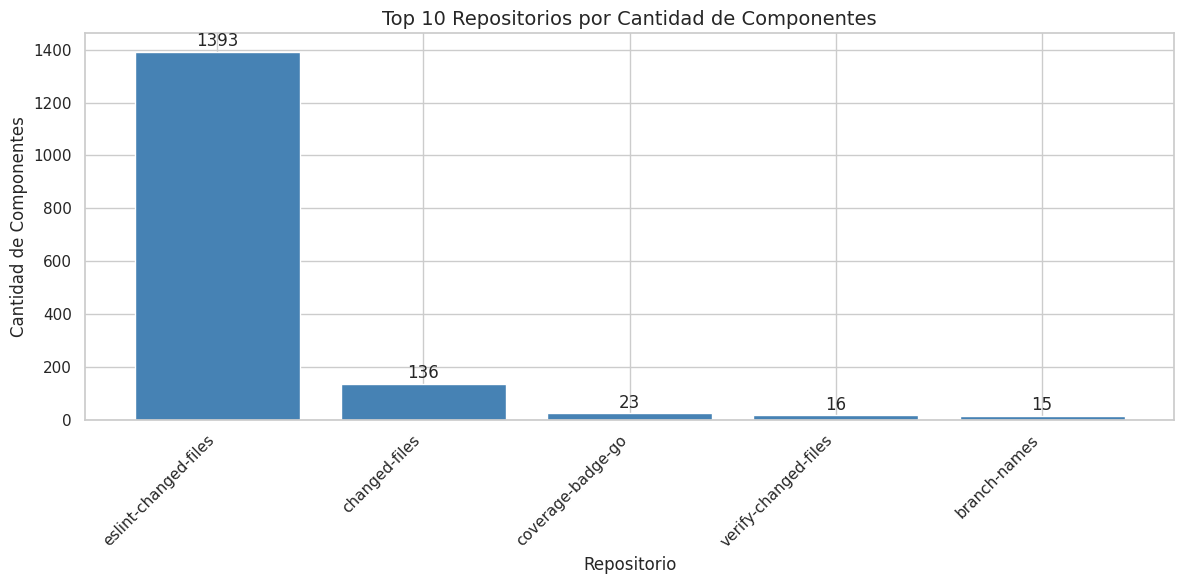

In [94]:
top_repos = df_components['repo'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_repos.index, top_repos.values, color='steelblue')
plt.title('Top 10 Repositorios por Cantidad de Componentes', fontsize=14)
plt.xlabel('Repositorio')
plt.ylabel('Cantidad de Componentes')
plt.xticks(rotation=45, ha='right')

for bar, value in zip(bars, top_repos.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Analizamos la distribuacion de componentes por ecosistema

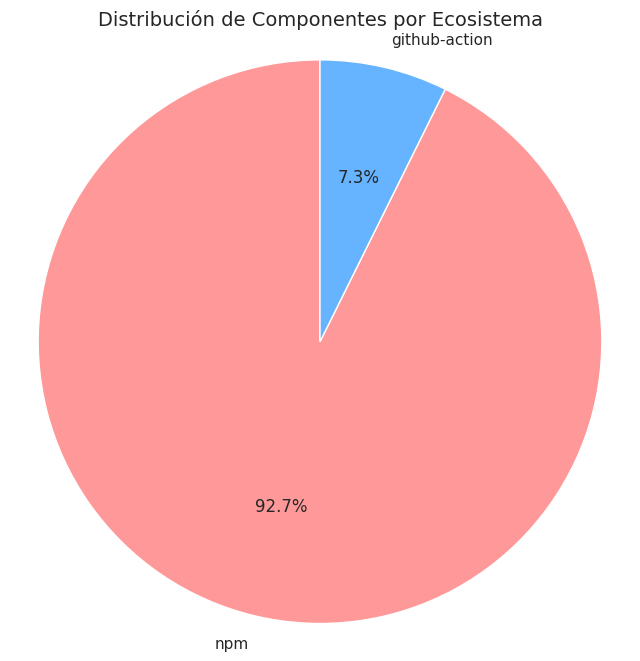

In [95]:
plt.figure(figsize=(8, 8))
ecosystem_counts = df_components['type'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
plt.pie(ecosystem_counts.values, labels=ecosystem_counts.index, 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribución de Componentes por Ecosistema', fontsize=14)
plt.axis('equal')
plt.show()

Componentes con identificador (CPE)

In [96]:
# Componentes que tienen CPE (identificadores de vulnerabilidad)
con_cpe = df_components[df_components['cpe_count'] > 0]
sin_cpe = df_components[df_components['cpe_count'] == 0]

print(f"Componentes CON CPE: {len(con_cpe)} ({len(con_cpe)/len(df_components)*100:.1f}%)")
print(f"Componentes SIN CPE: {len(sin_cpe)} ({len(sin_cpe)/len(df_components)*100:.1f}%)")

# Por ecosistema
print("\nComponentes con CPE por ecosistema:")
cpe_by_type = con_cpe.groupby('type').size().sort_values(ascending=False)
for eco, count in cpe_by_type.items():
    total_eco = ecosystem_counts[eco]
    pct = (count / total_eco) * 100
    print(f"  • {eco}: {count}/{total_eco} ({pct:.1f}%)")

Componentes CON CPE: 1583 (100.0%)
Componentes SIN CPE: 0 (0.0%)

Componentes con CPE por ecosistema:
  • npm: 1467/1467 (100.0%)
  • github-action: 116/116 (100.0%)


Exportamos los componentes a un DataFrame

In [97]:
output_path = Path("./results")
output_file = output_path / "componentes_consolidados.csv"
df_components.to_csv(output_file, index=False)

print(f"✓ DataFrame exportado exitosamente")
print(f"  Archivo: {output_file}")
print(f"  Registros: {len(df_components)}")

✓ DataFrame exportado exitosamente
  Archivo: results/componentes_consolidados.csv
  Registros: 1583


Exploramos la estructura de las vulnerabilidades analizando el primer archivo de vulnerabilidad


In [98]:
# Definimos la ruta a los resultados de vulnerabilidades
vuln_files = list(results_path.glob("*_vulns.json"))

if not vuln_files:
    print("No se encontraron archivos de vulnerabilidades '_vulns.json' en la carpeta '../results'.")
else:
    # Tomamos automáticamente el PRIMER archivo de la lista
    ruta_archivo = vuln_files[0]
    print(f"Archivo detectado: {ruta_archivo.name}")
    
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        matches = data.get('matches', [])
        print(f"- Total de vulnerabilidades (matches) encontradas: {len(matches)}")

        if len(matches) > 0:
            print("-  Estructura del primer hallazgo:")
            primer_match = matches[0]
            for key, value in primer_match.items():
                if isinstance(value, (str, int, float, bool)) or value is None:
                    print(f"  - {key}: {value}")
                elif isinstance(value, list):
                    print(f"  - {key}: [lista con {len(value)} elementos]")
                elif isinstance(value, dict):
                    print(f"  - {key}: {{diccionario con {len(value.keys())} llaves}}")
            
            print("- Primer hallazgo completo:")
            print(json.dumps(primer_match, indent=2)[:1000] + "\n...")
        else:
            print("No se encontraron vulnerabilidades en el archivo.")
            
    except json.JSONDecodeError:
        print(f"Error al leer el archivo {ruta_archivo.name}")

Archivo detectado: branch-names_vulns.json
- Total de vulnerabilidades (matches) encontradas: 0
No se encontraron vulnerabilidades en el archivo.


Definimos la funcion que usaremos para parsear las vulnerabilidades


In [99]:
def parse_vulnerabilidades(file_path, repo_name):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        matches = data.get("matches", [])
        vulns_list = []
        
        for m in matches:
            # Separamos la info de la vulnerabilidad y la info del paquete infectado
            v = m.get("vulnerability", {})
            a = m.get("artifact", {})
            
            vulns_list.append({
                "repositorio": repo_name,
                "componente": a.get("name", "Desconocido"),
                "ecosistema": a.get("language", "No especificado"),
                "vulnerabilidad_id": v.get("id", "Sin ID"),
                "severidad": v.get("severity", "Desconocida")
            })
            
        return vulns_list
        
    except json.JSONDecodeError:
        print(f"Error al leer el archivo JSON: {file_path.name}")
        return []

Analizamos las vulnerabilidades usando la funcion antes definida

In [100]:
all_vulnerabilities = []

for vuln_file in vuln_files:
    repo_name = vuln_file.stem.replace('_vulns', '')
    print(f"Procesando vulnerabilidades en {repo_name}...")
    vulns = parse_vulnerabilidades(vuln_file, repo_name)
    all_vulnerabilities.extend(vulns)
    print(f"- {len(vulns)} vulnerabilidades encontradas")

df_vulns = pd.DataFrame(all_vulnerabilities)

print(f"\n✓ DataFrame creado con {len(df_vulns)} vulnerabilidades totales")
print(f"  Columnas: {list(df_vulns.columns)}")

# Mostramos una muestra para verificar que todo salió bien
display(df_vulns.head())

Procesando vulnerabilidades en branch-names...
- 0 vulnerabilidades encontradas
Procesando vulnerabilidades en changed-files...
- 11 vulnerabilidades encontradas
Procesando vulnerabilidades en verify-changed-files...
- 0 vulnerabilidades encontradas
Procesando vulnerabilidades en eslint-changed-files...
- 60 vulnerabilidades encontradas
Procesando vulnerabilidades en coverage-badge-go...
- 0 vulnerabilidades encontradas

✓ DataFrame creado con 71 vulnerabilidades totales
  Columnas: ['repositorio', 'componente', 'ecosistema', 'vulnerabilidad_id', 'severidad']


,repositorio,componente,ecosistema,vulnerabilidad_id,severidad
0,changed-files,undici,javascript,GHSA-v9p9-hfj2-hcw8,High
1,changed-files,picomatch,javascript,GHSA-3v7f-55p6-f55p,Medium
2,changed-files,picomatch,javascript,GHSA-3v7f-55p6-f55p,Medium
3,changed-files,picomatch,javascript,GHSA-3v7f-55p6-f55p,Medium
4,changed-files,undici,javascript,GHSA-vrm6-8vpv-qv8q,High


Exportamos un DataFrame de Vulnerabilidades

In [101]:
# Exportar DataFrame de Vulnerabilidades
output_file_vulns = results_path / "vulnerabilidades_consolidadas.csv"
df_vulns.to_csv(output_file_vulns, index=False)

print(f"✓ Reporte de vulnerabilidades exportado a: {output_file_vulns}")


✓ Reporte de vulnerabilidades exportado a: results/vulnerabilidades_consolidadas.csv


Analizamos el nivel de las vulnerabilidades y su cantidad

Resumen por Severidad:
----------------------------------------
  • High      : 36    (50.7%)
  • Medium    : 27    (38.0%)
  • Low       : 8     (11.3%)
----------------------------------------
  TOTAL     : 71 vulnerabilidades



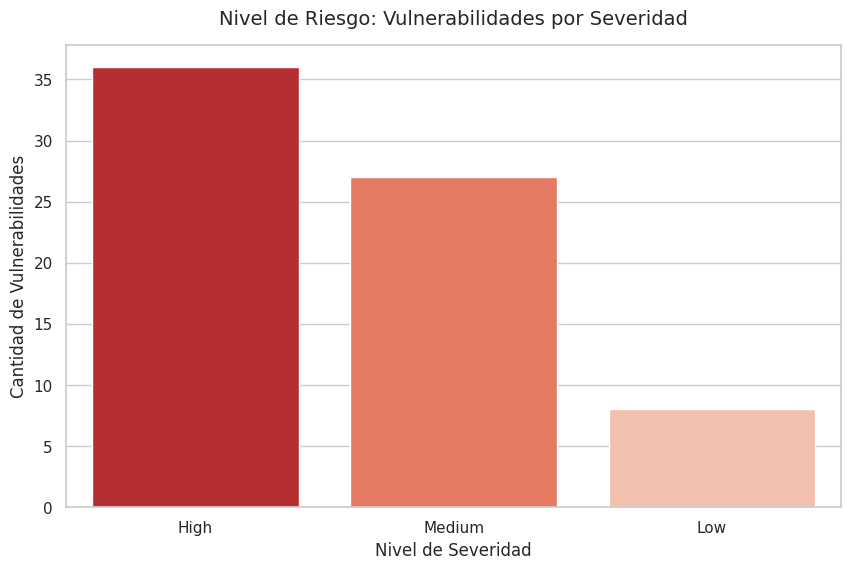

In [102]:
# 1. IMPRIMIR DATOS CRUDOS (Resumen Cuantitativo)
conteo_severidad = df_vulns['severidad'].value_counts()
total_vulns = len(df_vulns)

print("Resumen por Severidad:")
print("-" * 40)

# Definimos el orden lógico de las severidades
orden_severidad = ['Critical', 'High', 'Medium', 'Low', 'Negligible', 'Unknown']
orden_presente = [s for s in orden_severidad if s in df_vulns['severidad'].unique()]

# Iteramos sobre el orden lógico para imprimir ordenado
for severidad in orden_presente:
    cantidad = conteo_severidad.get(severidad, 0)
    porcentaje = (cantidad / total_vulns) * 100 if total_vulns > 0 else 0
    print(f"  • {severidad:<10}: {cantidad:<5} ({porcentaje:.1f}%)")

print("-" * 40)
print(f"  TOTAL     : {total_vulns} vulnerabilidades\n")


# 2. GENERAR EL GRÁFICO
plt.figure(figsize=(10, 6))

# Generar el gráfico de barras
sns.countplot(data=df_vulns, x='severidad', hue='severidad', order=orden_presente, palette='Reds_r', legend=False)

plt.title('Nivel de Riesgo: Vulnerabilidades por Severidad', fontsize=14, pad=15)
plt.xlabel('Nivel de Severidad')
plt.ylabel('Cantidad de Vulnerabilidades')

plt.show()

Analizamos la cantidad de vulnerabilidades por ecosistema (lenguaje) en el repositorio

📊 Resumen Cuantitativo por Ecosistema:
---------------------------------------------
  • javascript     : 71    (100.0%)
---------------------------------------------
  TOTAL          : 71 vulnerabilidades



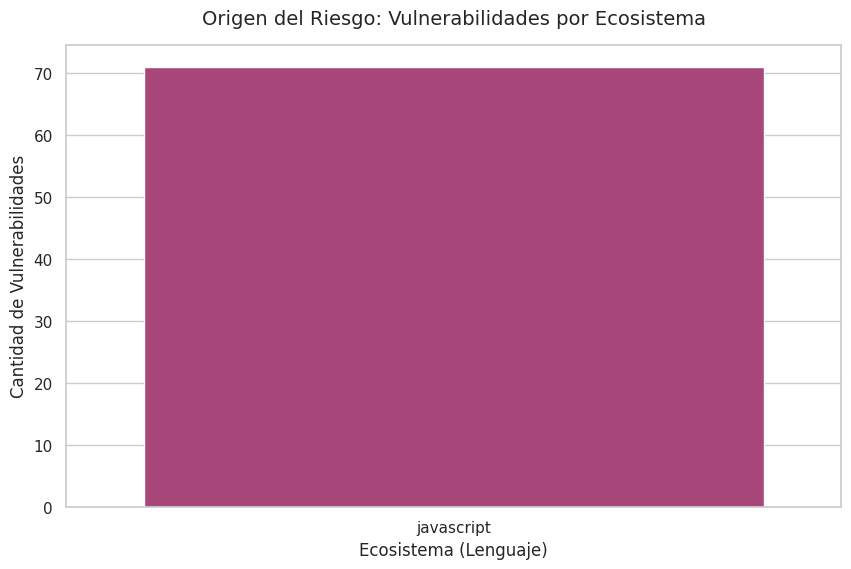

In [103]:
conteo_eco = df_vulns['ecosistema'].value_counts()
total_vulns = len(df_vulns)

print("📊 Resumen Cuantitativo por Ecosistema:")
print("-" * 45)

# Ordenamos de mayor a menor cantidad de vulnerabilidades
orden_eco = conteo_eco.index

# Iteramos para imprimir los datos crudos y porcentajes
for eco in orden_eco:
    cantidad = conteo_eco[eco]
    porcentaje = (cantidad / total_vulns) * 100 if total_vulns > 0 else 0
    # Usamos :<15 para alinear bien los nombres largos de los ecosistemas
    print(f"  • {eco:<15}: {cantidad:<5} ({porcentaje:.1f}%)")

print("-" * 45)
print(f"  TOTAL          : {total_vulns} vulnerabilidades\n")

# 2. GENERAR EL GRÁFICO
plt.figure(figsize=(10, 6))

# Generar gráfico
sns.countplot(data=df_vulns, x='ecosistema', hue='ecosistema', order=orden_eco, palette='magma', legend=False)

plt.title('Origen del Riesgo: Vulnerabilidades por Ecosistema', fontsize=14, pad=15)
plt.xlabel('Ecosistema (Lenguaje)')
plt.ylabel('Cantidad de Vulnerabilidades')

plt.show()

Analizamos las vulnerabilidades por repositorios

📊 Resumen Cuantitativo: Todos los Repositorios Analizados:
-----------------------------------------------------------------
  • eslint-changed-files          : 60    (84.5%)
  • changed-files                 : 11    (15.5%)
-----------------------------------------------------------------
  TOTAL GENERAL                  : 71 vulnerabilidades

  💡 NOTA: El Top 5 del gráfico representa el 100.0% de todos los riesgos (71/71)



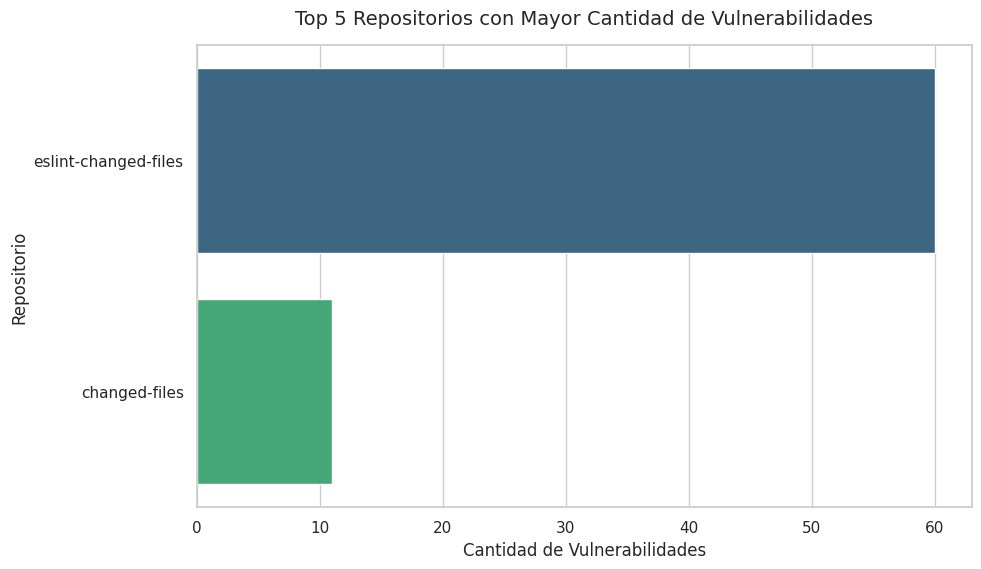

In [104]:
# 1. IMPRIMIR DATOS CRUDOS (Resumen Cuantitativo COMPLETO)
conteo_repos = df_vulns['repositorio'].value_counts()
total_vulns = len(df_vulns)

print("📊 Resumen Cuantitativo: Todos los Repositorios Analizados:")
print("-" * 65)

# Iteramos para imprimir TODOS los repositorios (sin límite)
for repo in conteo_repos.index:
    cantidad = conteo_repos[repo]
    porcentaje = (cantidad / total_vulns) * 100 if total_vulns > 0 else 0
    print(f"  • {repo:<30}: {cantidad:<5} ({porcentaje:.1f}%)")

print("-" * 65)
print(f"  TOTAL GENERAL                  : {total_vulns} vulnerabilidades\n")

# 2. GENERAR EL GRÁFICO (LIMITADO SOLO AL TOP 5)
top_repos = conteo_repos.head(5) # Aquí le ponemos el límite
suma_top5 = top_repos.sum()
pct_top5 = (suma_top5 / total_vulns) * 100 if total_vulns > 0 else 0

print(f"  💡 NOTA: El Top 5 del gráfico representa el {pct_top5:.1f}% de todos los riesgos ({suma_top5}/{total_vulns})\n")

plt.figure(figsize=(10, 6))

# Gráfico de barras horizontales usando solo 'top_repos'
sns.barplot(x=top_repos.values, y=top_repos.index, hue=top_repos.index, palette='viridis', legend=False)

plt.title('Top 5 Repositorios con Mayor Cantidad de Vulnerabilidades', fontsize=14, pad=15)
plt.xlabel('Cantidad de Vulnerabilidades')
plt.ylabel('Repositorio')

plt.show()

In [105]:
import json
import pandas as pd
from pathlib import Path

# Directorio donde están los resultados (ajusta si es necesario)
resultados_path = Path("./results")

# Buscar todos los archivos de workflows
archivos_json = list(resultados_path.glob("*_workflows.json"))

datos_consolidados = []

for archivo in archivos_json:
    with open(archivo, 'r', encoding='utf-8') as f:
        try:
            data = json.load(f)
            # Extender la lista solo si el archivo tiene datos
            if data:
                datos_consolidados.extend(data)
        except json.JSONDecodeError:
            print(f"Error al leer el archivo: {archivo}")

# Crear el DataFrame
df_workflows = pd.DataFrame(datos_consolidados)

# Guardar como CSV
ruta_csv = resultados_path / "workflows_consolidados.csv"
df_workflows.to_csv(ruta_csv, index=False, encoding='utf-8')

print(f"✓ Se procesaron {len(archivos_json)} archivos.")
print(f"✓ Se encontraron {len(df_workflows)} problemas en total.")
print(f"✓ Archivo guardado en: {ruta_csv}")

# Mostrar las primeras filas
display(df_workflows.head())

✓ Se procesaron 5 archivos.
✓ Se encontraron 3 problemas en total.
✓ Archivo guardado en: results/workflows_consolidados.csv


,repo,archivo,problema,severidad,categoria,linea
0,coverage-badge-go,test.yml,uso de GITHUB_TOKEN sin bloque de permissions ...,MEDIUM,CI/CD workflow,25
1,eslint-changed-files,test.yml,uso de GITHUB_TOKEN sin bloque de permissions ...,MEDIUM,CI/CD workflow,29
2,branch-names,test.yml,uso de pull_request_target (puede exponer secr...,HIGH,CI/CD workflow,69


In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

=== Datos Brutos: Riesgos por Repositorio ===
 - coverage-badge-go: 1 riesgo(s) detectado(s)
 - eslint-changed-files: 1 riesgo(s) detectado(s)
 - branch-names: 1 riesgo(s) detectado(s)

✓ Generando gráfico visual...



/tmp/ipykernel_1395/628714329.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


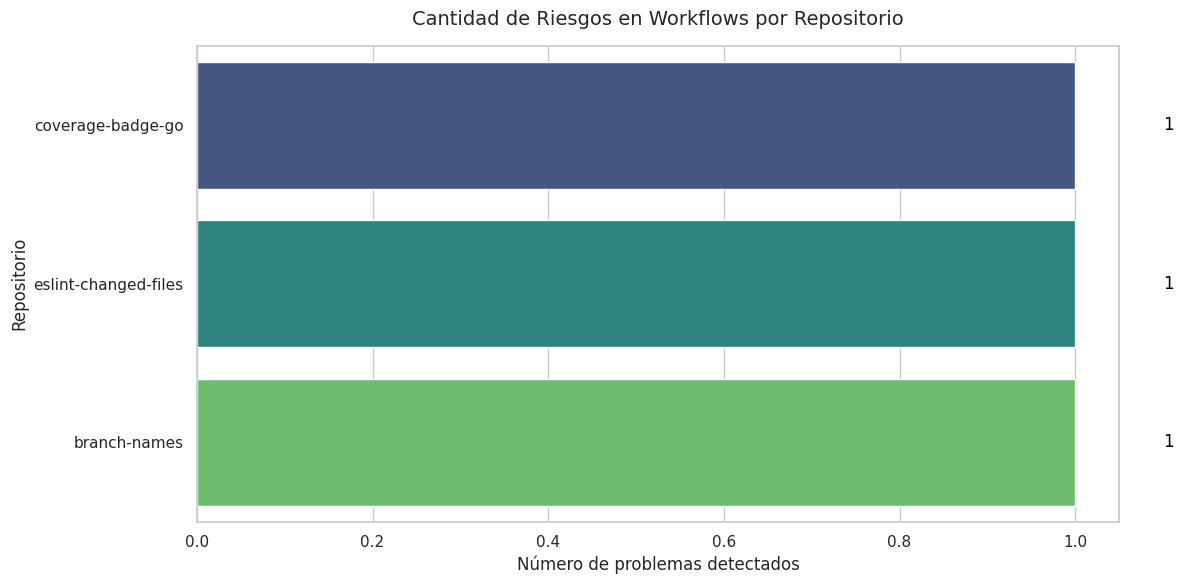

In [112]:
# Contar problemas por repositorio
conteo_repos = df_workflows['repo'].value_counts()

print("=== Datos Brutos: Riesgos por Repositorio ===")
# Iterar sobre todos los repositorios para mostrar los números exactos
for repo, cantidad in conteo_repos.items():
    print(f" - {repo}: {cantidad} riesgo(s) detectado(s)")

print("\n✓ Generando gráfico visual...\n")

# Generación del gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=conteo_repos.values, 
    y=conteo_repos.index, 
    palette="viridis"
)

plt.title('Cantidad de Riesgos en Workflows por Repositorio', fontsize=14, pad=15)
plt.xlabel('Número de problemas detectados', fontsize=12)
plt.ylabel('Repositorio', fontsize=12)

for i, v in enumerate(conteo_repos.values):
    ax.text(v + 0.1, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

=== Datos Brutos: Riesgos por Nivel de Severidad ===
 - Severidad MEDIUM: 2 hallazgo(s)
 - Severidad HIGH: 1 hallazgo(s)

✓ Generando gráfico visual...



/tmp/ipykernel_1395/3144539066.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


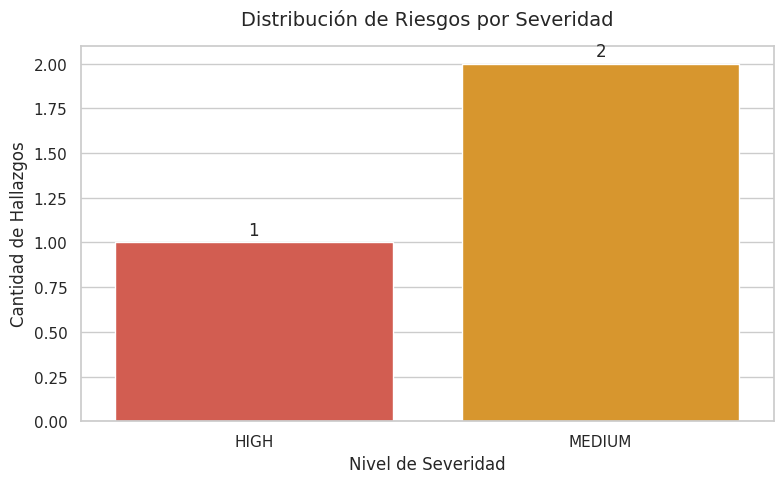

In [113]:
# Contar problemas por nivel de severidad
conteo_sev = df_workflows['severidad'].value_counts()

print("=== Datos Brutos: Riesgos por Nivel de Severidad ===")
# Iterar sobre las severidades encontradas y mostrar números exactos
for severidad, cantidad in conteo_sev.items():
    print(f" - Severidad {severidad}: {cantidad} hallazgo(s)")

print("\n✓ Generando gráfico visual...\n")

# Generación del gráfico
plt.figure(figsize=(8, 5))
colores_severidad = {"HIGH": "#e74c3c", "MEDIUM": "#f39c12", "LOW": "#3498db"}
orden_presente = [s for s in ['HIGH', 'MEDIUM', 'LOW'] if s in df_workflows['severidad'].unique()]

ax = sns.countplot(
    data=df_workflows, 
    x='severidad', 
    order=orden_presente,
    palette=colores_severidad
)

plt.title('Distribución de Riesgos por Severidad', fontsize=14, pad=15)
plt.xlabel('Nivel de Severidad', fontsize=12)
plt.ylabel('Cantidad de Hallazgos', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

=== Datos Brutos: Tipos de Riesgos/Malas Prácticas ===
 - [2 incidencias] uso de GITHUB_TOKEN sin bloque de permissions explícito
 - [1 incidencias] uso de pull_request_target (puede exponer secretos a PRs externos)

✓ Generando gráfico visual...



/tmp/ipykernel_1395/565433608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_1395/565433608.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_labels)


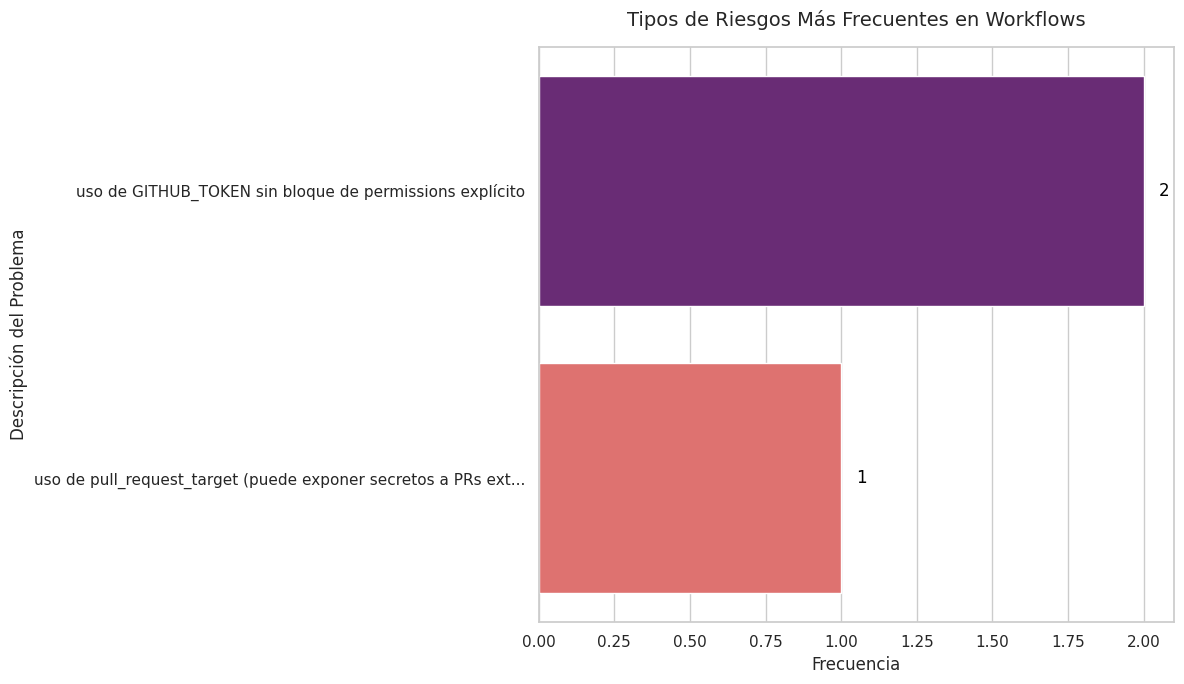

In [114]:
# Contar el tipo de problemas
conteo_problemas = df_workflows['problema'].value_counts()

print("=== Datos Brutos: Tipos de Riesgos/Malas Prácticas ===")
# Iterar sobre todos los tipos de problemas para mostrar en qué volumen ocurren
for problema, cantidad in conteo_problemas.items():
    print(f" - [{cantidad} incidencias] {problema}")

print("\n✓ Generando gráfico visual...\n")

# Generación del gráfico
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=conteo_problemas.values, 
    y=conteo_problemas.index, 
    palette="magma"
)

plt.title('Tipos de Riesgos Más Frecuentes en Workflows', fontsize=14, pad=15)
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Descripción del Problema', fontsize=12)

y_labels = [label.get_text()[:60] + '...' if len(label.get_text()) > 60 else label.get_text() for label in ax.get_yticklabels()]
ax.set_yticklabels(y_labels)

for i, v in enumerate(conteo_problemas.values):
    ax.text(v + 0.05, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

## Conclusiones

### Hallazgos principales:
- Por insertar





### Archivos generados:
- `results/componentes_consolidados.csv` - Dataset consolidado para análisis de componentes
- `results/vulnerabilidades_consolidadas.csv`- Dataset consolidado para análisis de vulnerabilidades